# Fold Analysis
Investigates the 5-fold cross-validation splits:
- Video counts per fold (train / val)
- Institution distribution per fold
- Frame-level class distribution per fold
- Cross-fold consistency checks

> **Note:** Class distribution cells require access to the `.h5` files.
> Institution / video count cells only need `splits.json`.

In [1]:
import os
import json
from collections import defaultdict

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
# Try local workspace first, fall back to server path
_LOCAL_SPLITS  = os.path.join(os.path.dirname(os.getcwd()), 'splits.json')   # ../splits.json
_LOCAL_SPLITS2 = os.path.join(os.getcwd(), '..', 'splits.json')
_SERVER_SPLITS = '/code/jjiang23/pathml/aim2_balanceV2/data/splits.json'

for _candidate in [_LOCAL_SPLITS, _LOCAL_SPLITS2, _SERVER_SPLITS]:
    if os.path.exists(_candidate):
        SPLITS_PATH = os.path.abspath(_candidate)
        break
else:
    raise FileNotFoundError(
        f'splits.json not found. Tried:\n  {_LOCAL_SPLITS}\n  {_SERVER_SPLITS}'
    )

print(f'Using splits: {SPLITS_PATH}')

# Label map — matches PoseDataset
LABEL_MAP = {
    b'Phase1':   0,
    b'Phase2':   1,
    b'Phase3':   2,
    b'Phase4':   3,
    b'nonphase': 4,
}
LABEL_NAMES = ['Phase1', 'Phase2', 'Phase3', 'Phase4', 'nonphase']
PHASE_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#937860']

Using splits: /code/jjiang23/BalanceTestThesis/splits.json


## 1 — Load Splits & Basic Stats

In [3]:
with open(SPLITS_PATH) as f:
    splits = json.load(f)

fold_names = list(splits.keys())
n_folds    = len(fold_names)

# Collect per-file info from paths (no h5 needed)
def institution_from_path(path):
    """Extract institution tag from parent directory name."""
    return os.path.basename(os.path.dirname(path))

def subject_id_from_path(path):
    """Best-effort subject ID from filename stem."""
    stem = os.path.splitext(os.path.basename(path))[0]
    return stem

# Print quick overview
all_files = set()
print(f"{'Fold':<10} {'Train':>8} {'Val':>6}")
print('-' * 28)
for fold in fold_names:
    tr = splits[fold]['train']
    vl = splits[fold]['val']
    print(f"{fold:<10} {len(tr):>8} {len(vl):>6}")
    all_files.update(tr)
    all_files.update(vl)

print(f"{'TOTAL unique':<10} {len(all_files):>8}")

# All institutions in the dataset
all_institutions = sorted({institution_from_path(p) for p in all_files})
print(f"\nInstitutions: {all_institutions}")

Fold          Train    Val
----------------------------
fold_0           96     32
fold_1          104     24
fold_2          105     23
fold_3          104     24
fold_4          103     25
TOTAL unique      128

Institutions: ['cp', 'uwisc', 'va']


## 2 — Video Counts per Fold

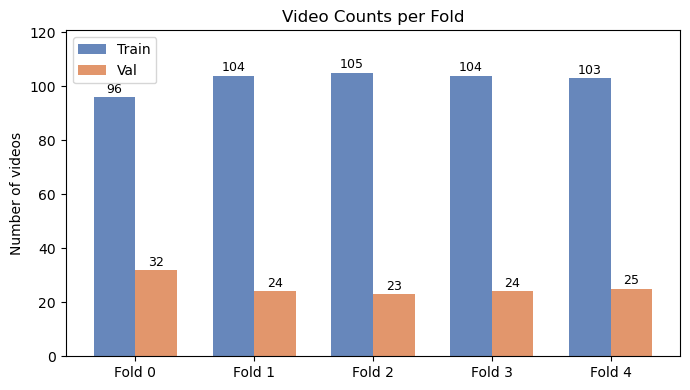


Train/val ratio: 4.00x  (~80% / 20%)


In [4]:
train_counts = [len(splits[f]['train']) for f in fold_names]
val_counts   = [len(splits[f]['val'])   for f in fold_names]

x = np.arange(n_folds)
w = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - w/2, train_counts, w, label='Train', color='#4C72B0', alpha=0.85)
b2 = ax.bar(x + w/2, val_counts,   w, label='Val',   color='#DD8452', alpha=0.85)

for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f.replace('fold_', 'Fold ') for f in fold_names])
ax.set_ylabel('Number of videos')
ax.set_title('Video Counts per Fold')
ax.legend()
ax.set_ylim(0, max(train_counts) * 1.15)
plt.tight_layout()
plt.show()

print(f"\nTrain/val ratio: {np.mean(train_counts)/np.mean(val_counts):.2f}x  "
      f"(~{np.mean(train_counts)/(np.mean(train_counts)+np.mean(val_counts))*100:.0f}% / "
      f"{np.mean(val_counts)/(np.mean(train_counts)+np.mean(val_counts))*100:.0f}%)")

## 3 — Institution Distribution per Fold

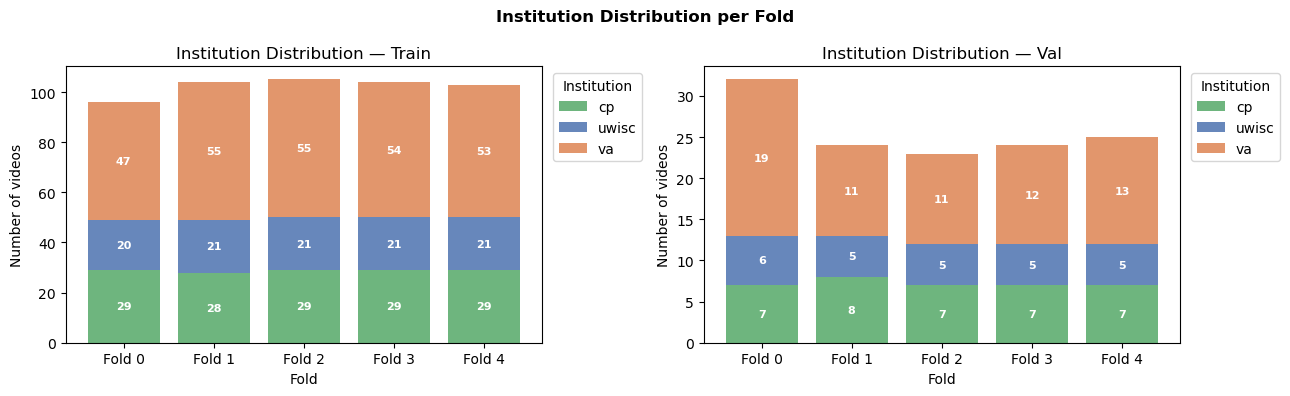

In [5]:
# Build per-fold institution counts for train/val
inst_colors = {'uwisc': '#4C72B0', 'va': '#DD8452', 'cp': '#55A868'}
# Fall back to tab10 for any unseen institution
_fallback = plt.cm.tab10(np.linspace(0, 0.9, 10))
_fi = 0
for inst in all_institutions:
    if inst not in inst_colors:
        inst_colors[inst] = _fallback[_fi]; _fi += 1

def count_institutions(file_list):
    """Return dict {institution: count} from a list of file paths."""
    counts = defaultdict(int)
    for p in file_list:
        counts[institution_from_path(p)] += 1
    return counts

train_inst = [count_institutions(splits[f]['train']) for f in fold_names]
val_inst   = [count_institutions(splits[f]['val'])   for f in fold_names]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, records, title in [
    (axes[0], train_inst, 'Train'),
    (axes[1], val_inst,   'Val'),
]:
    bottoms = np.zeros(n_folds)
    for inst in all_institutions:
        vals = np.array([r.get(inst, 0) for r in records], dtype=float)
        bars = ax.bar(fold_names, vals, bottom=bottoms, label=inst,
                      color=inst_colors[inst], alpha=0.85)
        # Annotate only segments that are visible
        for bar, v, bot in zip(bars, vals, bottoms):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bot + v/2,
                        str(int(v)), ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        bottoms += vals
    ax.set_title(f'Institution Distribution — {title}')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Number of videos')
    ax.set_xticklabels([f.replace('fold_', 'Fold ') for f in fold_names])
    ax.legend(title='Institution', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Institution Distribution per Fold', fontweight='bold')
plt.tight_layout()
plt.show()

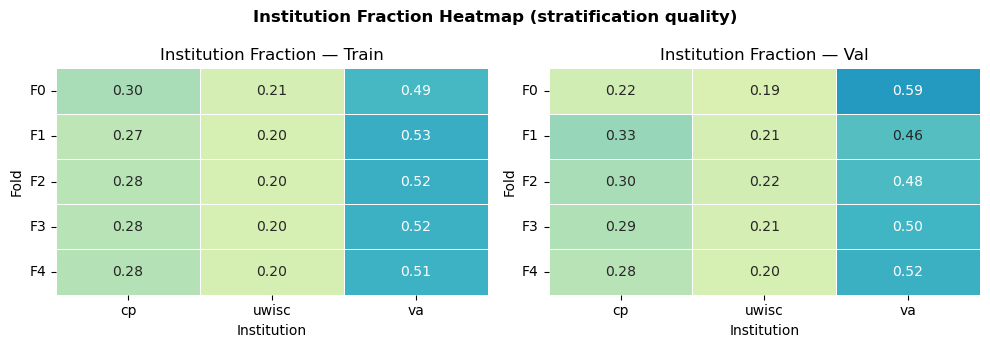

In [6]:
# Heatmap: institution fraction per fold (train / val side by side)
def inst_fraction_df(records_list, fold_names):
    rows = []
    for fold, rec in zip(fold_names, records_list):
        total = sum(rec.values())
        row = {'fold': fold}
        for inst in all_institutions:
            row[inst] = rec.get(inst, 0) / total if total > 0 else 0
        rows.append(row)
    return pd.DataFrame(rows).set_index('fold')

df_tr = inst_fraction_df(train_inst, fold_names)
df_vl = inst_fraction_df(val_inst,   fold_names)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, df, title in [(axes[0], df_tr, 'Train'), (axes[1], df_vl, 'Val')]:
    sns.heatmap(df, ax=ax, annot=True, fmt='.2f', cmap='YlGnBu',
                vmin=0, vmax=1, cbar=False, linewidths=0.5)
    ax.set_title(f'Institution Fraction — {title}')
    ax.set_xlabel('Institution')
    ax.set_ylabel('Fold')
    ax.set_yticklabels([f.replace('fold_', 'F') for f in fold_names], rotation=0)

plt.suptitle('Institution Fraction Heatmap (stratification quality)', fontweight='bold')
plt.tight_layout()
plt.show()

## 4 — Frame-Level Class Distribution per Fold

Requires access to `.h5` files. Skips any paths that are not accessible.

In [7]:
def load_labels(file_list, verbose=False):
    """
    Load frame-level labels from h5 files.
    Returns a 1D array of integer labels (0-4) and list of (path, n_frames) for accessible files.
    """
    all_labels = []
    meta       = []   # (path, n_frames, institution)
    skipped    = 0
    for path in file_list:
        try:
            with h5py.File(path, 'r') as f:
                raw = f['camera_poses_labels'][:]
            labels = np.array([LABEL_MAP[lbl] for lbl in raw], dtype=np.int32)
            all_labels.append(labels)
            meta.append((path, len(labels), institution_from_path(path)))
        except Exception:
            skipped += 1
    if verbose and skipped:
        print(f'  Skipped {skipped}/{len(file_list)} inaccessible files')
    return (
        np.concatenate(all_labels) if all_labels else np.array([], dtype=np.int32),
        meta,
    )

# Load all folds (this reads labels only — no keypoints)
print('Loading frame labels from h5 files...')
fold_label_data = {}   # fold_name → {'train': (labels, meta), 'val': (labels, meta)}

for fold in fold_names:
    print(f'  {fold}', end='', flush=True)
    tr_labels, tr_meta = load_labels(splits[fold]['train'], verbose=True)
    vl_labels, vl_meta = load_labels(splits[fold]['val'],   verbose=True)
    fold_label_data[fold] = {
        'train': (tr_labels, tr_meta),
        'val':   (vl_labels, vl_meta),
    }
    tr_videos = len(tr_meta)
    vl_videos = len(vl_meta)
    print(f'  train: {len(tr_labels):,} frames ({tr_videos} videos)   '
          f'val: {len(vl_labels):,} frames ({vl_videos} videos)')

# Check if any h5 data was loaded
_any_loaded = any(
    len(fold_label_data[f]['train'][0]) > 0
    for f in fold_names
)
if not _any_loaded:
    print('\n⚠  No h5 files accessible — class distribution plots will be skipped.')
    print('   Run this notebook on the server where h5 files are mounted.')
else:
    print('\n✓ Labels loaded successfully')

Loading frame labels from h5 files...
  fold_0  train: 221,891 frames (96 videos)   val: 59,141 frames (32 videos)
  fold_1  train: 223,636 frames (104 videos)   val: 57,396 frames (24 videos)
  fold_2  train: 227,601 frames (105 videos)   val: 53,431 frames (23 videos)
  fold_3  train: 224,836 frames (104 videos)   val: 56,196 frames (24 videos)
  fold_4  train: 226,164 frames (103 videos)   val: 54,868 frames (25 videos)

✓ Labels loaded successfully


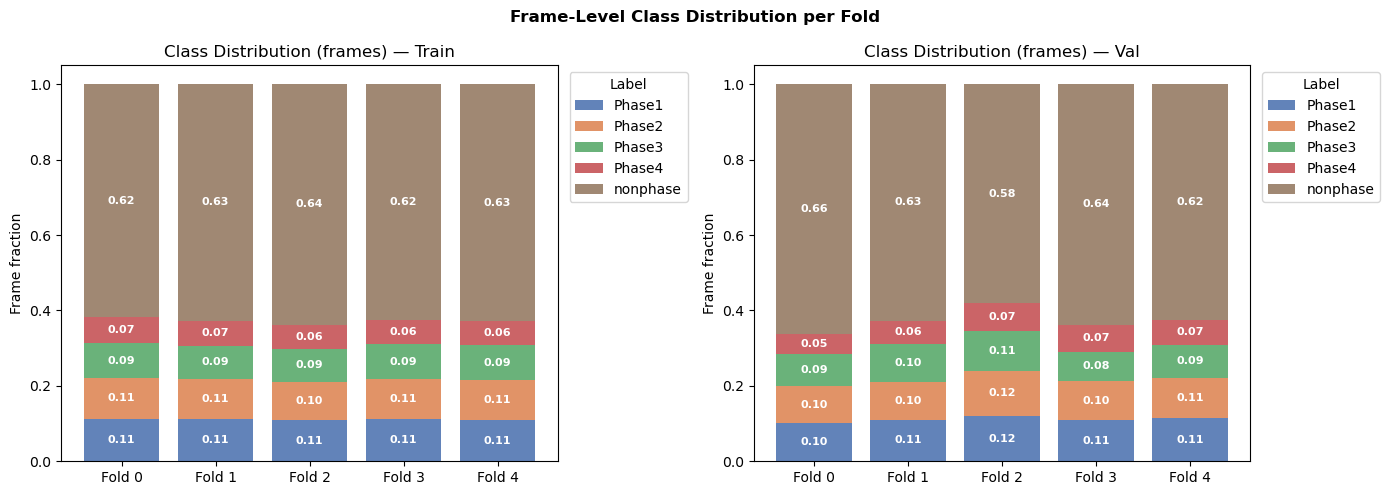

In [8]:
if not _any_loaded:
    print('Skipping — no h5 data available.')
else:
    # Per-fold class distribution: stacked bars, train vs val
    n_classes = len(LABEL_NAMES)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, split_key, split_title in [
        (axes[0], 'train', 'Train'),
        (axes[1], 'val',   'Val'),
    ]:
        # Build (fold × class) count matrix
        count_mat = np.zeros((n_folds, n_classes), dtype=float)
        for i, fold in enumerate(fold_names):
            labels, _ = fold_label_data[fold][split_key]
            if len(labels):
                for c in range(n_classes):
                    count_mat[i, c] = (labels == c).sum()

        # Normalise to fraction
        row_sums = count_mat.sum(axis=1, keepdims=True)
        frac_mat = np.divide(count_mat, row_sums, where=row_sums > 0)

        bottoms = np.zeros(n_folds)
        x_pos   = np.arange(n_folds)
        for c in range(n_classes):
            bars = ax.bar(x_pos, frac_mat[:, c], bottom=bottoms,
                          label=LABEL_NAMES[c], color=PHASE_COLORS[c], alpha=0.88)
            for bar, frac, bot in zip(bars, frac_mat[:, c], bottoms):
                if frac > 0.04:
                    ax.text(bar.get_x() + bar.get_width()/2, bot + frac/2,
                            f'{frac:.2f}', ha='center', va='center',
                            fontsize=8, color='white', fontweight='bold')
            bottoms += frac_mat[:, c]

        ax.set_xticks(x_pos)
        ax.set_xticklabels([f.replace('fold_', 'Fold ') for f in fold_names])
        ax.set_ylabel('Frame fraction')
        ax.set_ylim(0, 1.05)
        ax.set_title(f'Class Distribution (frames) — {split_title}')
        ax.legend(title='Label', bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.suptitle('Frame-Level Class Distribution per Fold', fontweight='bold')
    plt.tight_layout()
    plt.show()

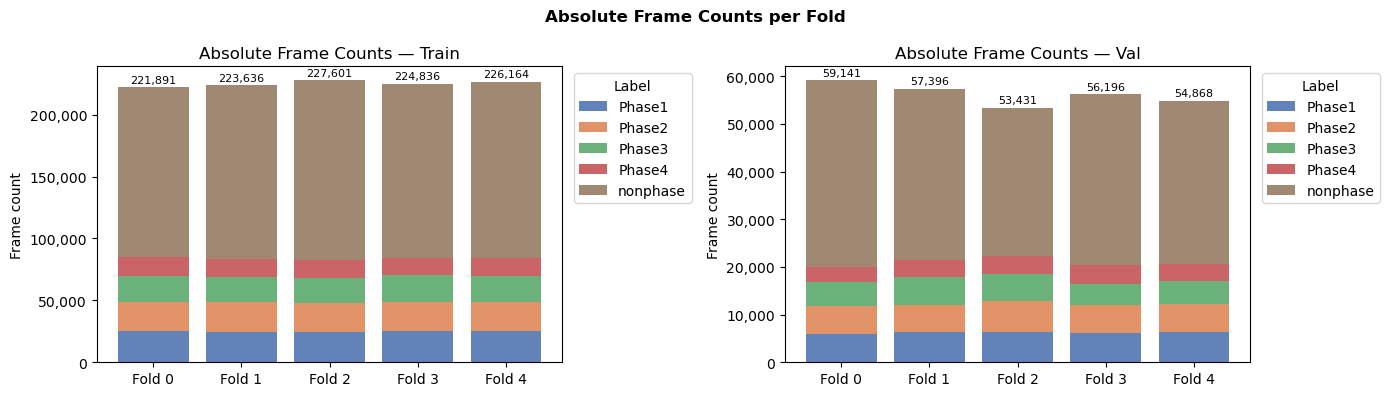

In [9]:
if not _any_loaded:
    print('Skipping — no h5 data available.')
else:
    # Absolute frame counts per fold (useful to spot leakage / imbalanced fold sizes)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for ax, split_key, split_title in [
        (axes[0], 'train', 'Train'),
        (axes[1], 'val',   'Val'),
    ]:
        count_mat = np.zeros((n_folds, n_classes), dtype=float)
        for i, fold in enumerate(fold_names):
            labels, _ = fold_label_data[fold][split_key]
            for c in range(n_classes):
                count_mat[i, c] = (labels == c).sum() if len(labels) else 0

        bottoms = np.zeros(n_folds)
        x_pos   = np.arange(n_folds)
        for c in range(n_classes):
            ax.bar(x_pos, count_mat[:, c], bottom=bottoms,
                   label=LABEL_NAMES[c], color=PHASE_COLORS[c], alpha=0.88)
            bottoms += count_mat[:, c]

        # Total labels above bars
        for i, fold in enumerate(fold_names):
            total = int(count_mat[i].sum())
            ax.text(i, total + total*0.01, f'{total:,}', ha='center', va='bottom',
                    fontsize=8)

        ax.set_xticks(x_pos)
        ax.set_xticklabels([f.replace('fold_', 'Fold ') for f in fold_names])
        ax.set_ylabel('Frame count')
        ax.set_title(f'Absolute Frame Counts — {split_title}')
        ax.legend(title='Label', bbox_to_anchor=(1.01, 1), loc='upper left')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

    plt.suptitle('Absolute Frame Counts per Fold', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5 — Class Distribution Heatmap (stratification quality)

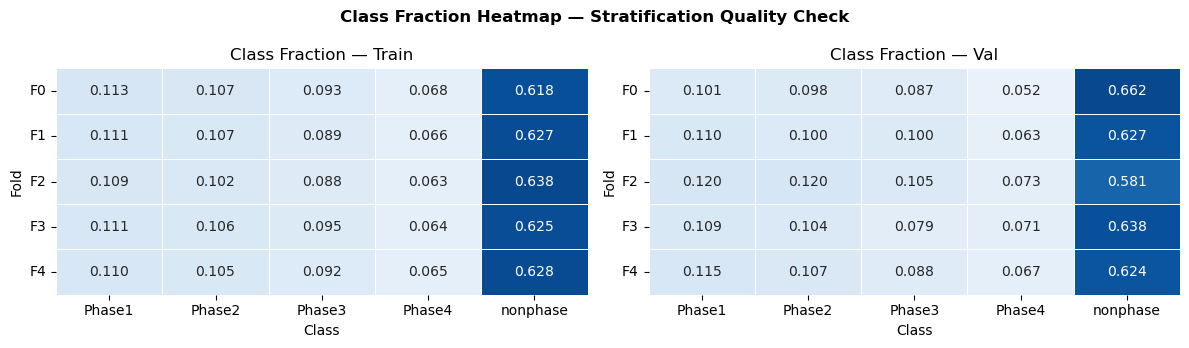


Std of class fraction across folds (lower = more consistent):
  train:
    Phase1       mean=0.111  std=0.0018
    Phase2       mean=0.105  std=0.0021
    Phase3       mean=0.091  std=0.0026
    Phase4       mean=0.065  std=0.0021
    nonphase     mean=0.627  std=0.0072
  val:
    Phase1       mean=0.111  std=0.0071
    Phase2       mean=0.106  std=0.0087
    Phase3       mean=0.091  std=0.0106
    Phase4       mean=0.065  std=0.0083
    nonphase     mean=0.626  std=0.0293


In [10]:
if not _any_loaded:
    print('Skipping — no h5 data available.')
else:
    # Heatmap: rows=folds, cols=classes, value=fraction — train and val side by side
    def build_frac_df(split_key):
        rows = []
        for fold in fold_names:
            labels, _ = fold_label_data[fold][split_key]
            total = len(labels)
            row = {'fold': fold}
            for c, name in enumerate(LABEL_NAMES):
                row[name] = (labels == c).sum() / total if total > 0 else 0
            rows.append(row)
        return pd.DataFrame(rows).set_index('fold')

    df_tr_cls = build_frac_df('train')
    df_vl_cls = build_frac_df('val')

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    for ax, df, title in [(axes[0], df_tr_cls, 'Train'), (axes[1], df_vl_cls, 'Val')]:
        sns.heatmap(df, ax=ax, annot=True, fmt='.3f', cmap='Blues',
                    vmin=0, vmax=df.values.max() * 1.1, cbar=False, linewidths=0.5)
        ax.set_title(f'Class Fraction — {title}')
        ax.set_xlabel('Class')
        ax.set_ylabel('Fold')
        ax.set_yticklabels([f.replace('fold_', 'F') for f in fold_names], rotation=0)

    plt.suptitle('Class Fraction Heatmap — Stratification Quality Check', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Also print std across folds — lower = better stratification
    print('\nStd of class fraction across folds (lower = more consistent):')
    for split_key, df in [('train', df_tr_cls), ('val', df_vl_cls)]:
        print(f'  {split_key}:')
        for col in df.columns:
            print(f'    {col:<12} mean={df[col].mean():.3f}  std={df[col].std():.4f}')

## 6 — Institution × Class Co-occurrence (per fold)

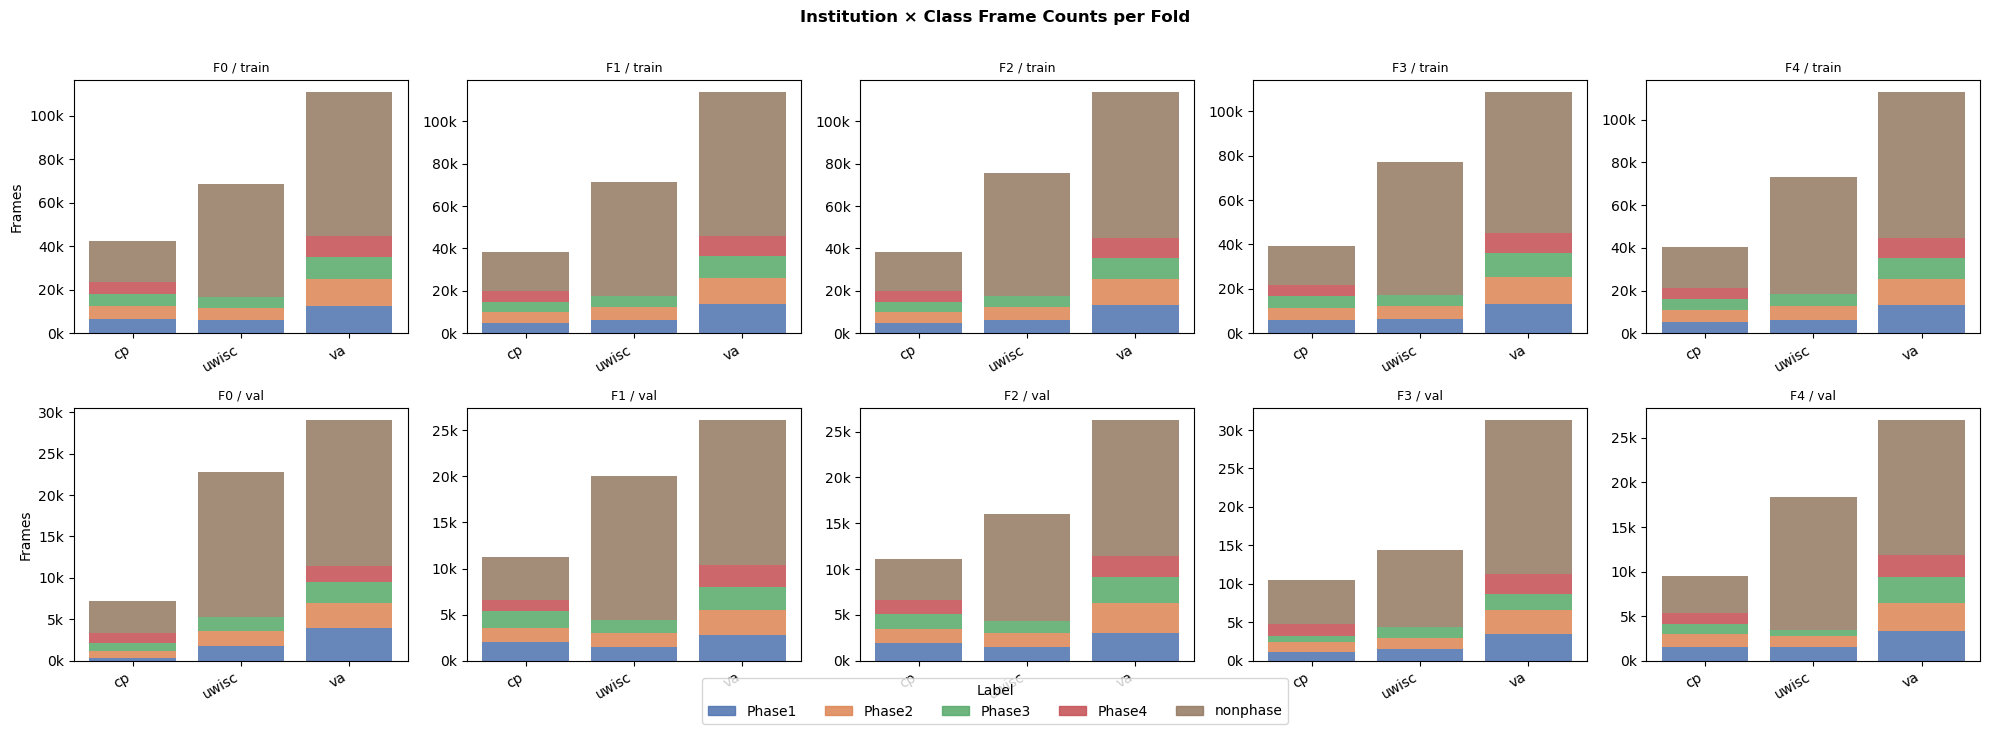

In [11]:
if not _any_loaded:
    print('Skipping — no h5 data available.')
else:
    # For each fold × split, show how many frames of each class come from each institution
    # One figure with 2 rows (train/val) × n_folds columns
    fig, axes = plt.subplots(2, n_folds, figsize=(4 * n_folds, 7), sharey=False)

    for row_idx, split_key in enumerate(['train', 'val']):
        for col_idx, fold in enumerate(fold_names):
            ax = axes[row_idx][col_idx]
            labels, meta = fold_label_data[fold][split_key]

            if len(labels) == 0:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                        transform=ax.transAxes)
                ax.set_title(f'{fold} / {split_key}')
                continue

            # Build per-video class counts
            inst_class_counts = defaultdict(lambda: np.zeros(len(LABEL_NAMES)))
            ptr = 0
            for path, n_frames, inst in meta:
                vid_labels = labels[ptr:ptr + n_frames]
                ptr += n_frames
                for c in range(len(LABEL_NAMES)):
                    inst_class_counts[inst][c] += (vid_labels == c).sum()

            insts_present = sorted(inst_class_counts.keys())
            x_pos   = np.arange(len(insts_present))
            bottoms = np.zeros(len(insts_present))

            for c in range(len(LABEL_NAMES)):
                vals = np.array([inst_class_counts[inst][c] for inst in insts_present])
                ax.bar(x_pos, vals, bottom=bottoms,
                       label=LABEL_NAMES[c], color=PHASE_COLORS[c], alpha=0.85)
                bottoms += vals

            ax.set_xticks(x_pos)
            ax.set_xticklabels(insts_present, rotation=30, ha='right')
            ax.set_title(f'{fold.replace("fold_", "F")} / {split_key}', fontsize=9)
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v/1000)}k'))
            if col_idx == 0:
                ax.set_ylabel('Frames')

    # Single shared legend
    handles = [plt.Rectangle((0,0),1,1, color=PHASE_COLORS[c], alpha=0.85)
               for c in range(len(LABEL_NAMES))]
    fig.legend(handles, LABEL_NAMES, title='Label',
               loc='lower center', ncol=len(LABEL_NAMES), bbox_to_anchor=(0.5, -0.02))

    plt.suptitle('Institution × Class Frame Counts per Fold', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

## 7 — Summary Table

In [12]:
rows = []
for fold in fold_names:
    for split_key in ['train', 'val']:
        inst_counts = count_institutions(
            splits[fold][split_key]
        )
        n_videos = len(splits[fold][split_key])
        row = {'fold': fold, 'split': split_key, 'videos': n_videos}
        for inst in all_institutions:
            row[f'n_{inst}'] = inst_counts.get(inst, 0)
            row[f'pct_{inst}'] = f"{inst_counts.get(inst, 0)/n_videos*100:.1f}%"

        if _any_loaded:
            labels, _ = fold_label_data[fold][split_key]
            total_frames = len(labels)
            row['total_frames'] = total_frames
            for c, name in enumerate(LABEL_NAMES):
                cnt = (labels == c).sum()
                row[f'frames_{name}'] = cnt
                row[f'pct_{name}'] = f"{cnt/total_frames*100:.1f}%" if total_frames > 0 else 'N/A'

        rows.append(row)

df_summary = pd.DataFrame(rows)
display_cols = ['fold', 'split', 'videos'] + [f'n_{i}' for i in all_institutions]
if _any_loaded:
    display_cols += ['total_frames'] + [f'frames_{n}' for n in LABEL_NAMES] + [f'pct_{n}' for n in LABEL_NAMES]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(df_summary[display_cols].to_string(index=False))

  fold split  videos  n_cp  n_uwisc  n_va  total_frames  frames_Phase1  frames_Phase2  frames_Phase3  frames_Phase4  frames_nonphase pct_Phase1 pct_Phase2 pct_Phase3 pct_Phase4 pct_nonphase
fold_0 train      96    29       20    47        221891          25167          23851          20557          15198           137118      11.3%      10.7%       9.3%       6.8%        61.8%
fold_0   val      32     7        6    19         59141           5988           5767           5119           3098            39169      10.1%       9.8%       8.7%       5.2%        66.2%
fold_1 train     104    28       21    55        223636          24822          23850          19965          14688           140311      11.1%      10.7%       8.9%       6.6%        62.7%
fold_1   val      24     8        5    11         57396           6333           5768           5711           3608            35976      11.0%      10.0%      10.0%       6.3%        62.7%
fold_2 train     105    29       21    55        2